# 01. 탐색적 데이터 분석 (EDA)
Netflix 고객 이탈 현황 분석

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [17]:
df = pd.read_csv('../data/raw/netflix_customer_churn.csv')
print(f'데이터: {df.shape}')
df.head()

데이터: (5000, 14)


,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: float64(3), int64(4), object(7)
memor

In [19]:
df.describe()

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.847400,11.649450,30.089800,13.683400,0.503000,3.024400,0.874800
std,15.501128,12.014654,17.536078,3.692062,0.500041,1.415841,2.619824
min,18.000000,0.010000,0.000000,8.990000,0.000000,1.000000,0.000000
25%,30.000000,3.337500,15.000000,8.990000,0.000000,2.000000,0.110000
50%,44.000000,8.000000,30.000000,13.990000,1.000000,3.000000,0.290000
75%,58.000000,16.030000,45.000000,17.990000,1.000000,4.000000,0.720000
max,70.000000,110.400000,60.000000,17.990000,1.000000,5.000000,98.420000


In [20]:
# 결측치 확인
print('=== 결측치 현황 ===')
print(df.isnull().sum())

=== 결측치 현황 ===
customer_id               0
age                       0
gender                    0
subscription_type         0
watch_hours               0
last_login_days           0
region                    0
device                    0
monthly_fee               0
churned                   0
payment_method            0
number_of_profiles        0
avg_watch_time_per_day    0
favorite_genre            0
dtype: int64


---
## 1. 타겟변수 분포 확인
- 이탈/유지 고객 수 바차트
- 이탈 비율 파이차트 (약 50:50 균형 확인)

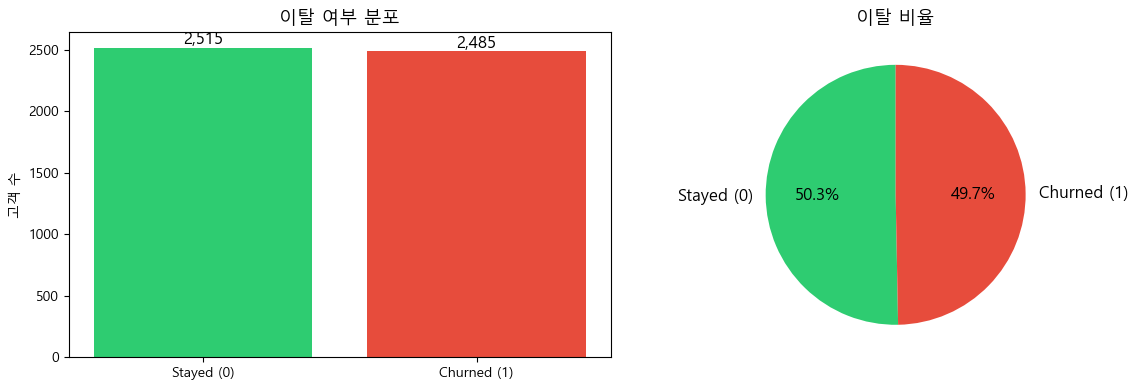

이탈률: 50.30%


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['churned'].value_counts()
labels = ['Stayed (0)', 'Churned (1)']
colors = ['#2ecc71', '#e74c3c']

# 바차트
axes[0].bar(labels, counts.values, color=colors)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontsize=12)
axes[0].set_title('이탈 여부 분포', fontsize=13)
axes[0].set_ylabel('고객 수')

# 파이차트
axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1].set_title('이탈 비율', fontsize=13)

plt.tight_layout()
plt.show()

print(f'이탈률: {df["churned"].mean():.2%}')

---
## 2. 수치형 변수의 분포, 이상치 확인
- 이탈/잔류별 히스토그램 비교
- 이탈 여부별 박스플롯
- 이탈 vs 잔류 평균값 비교표

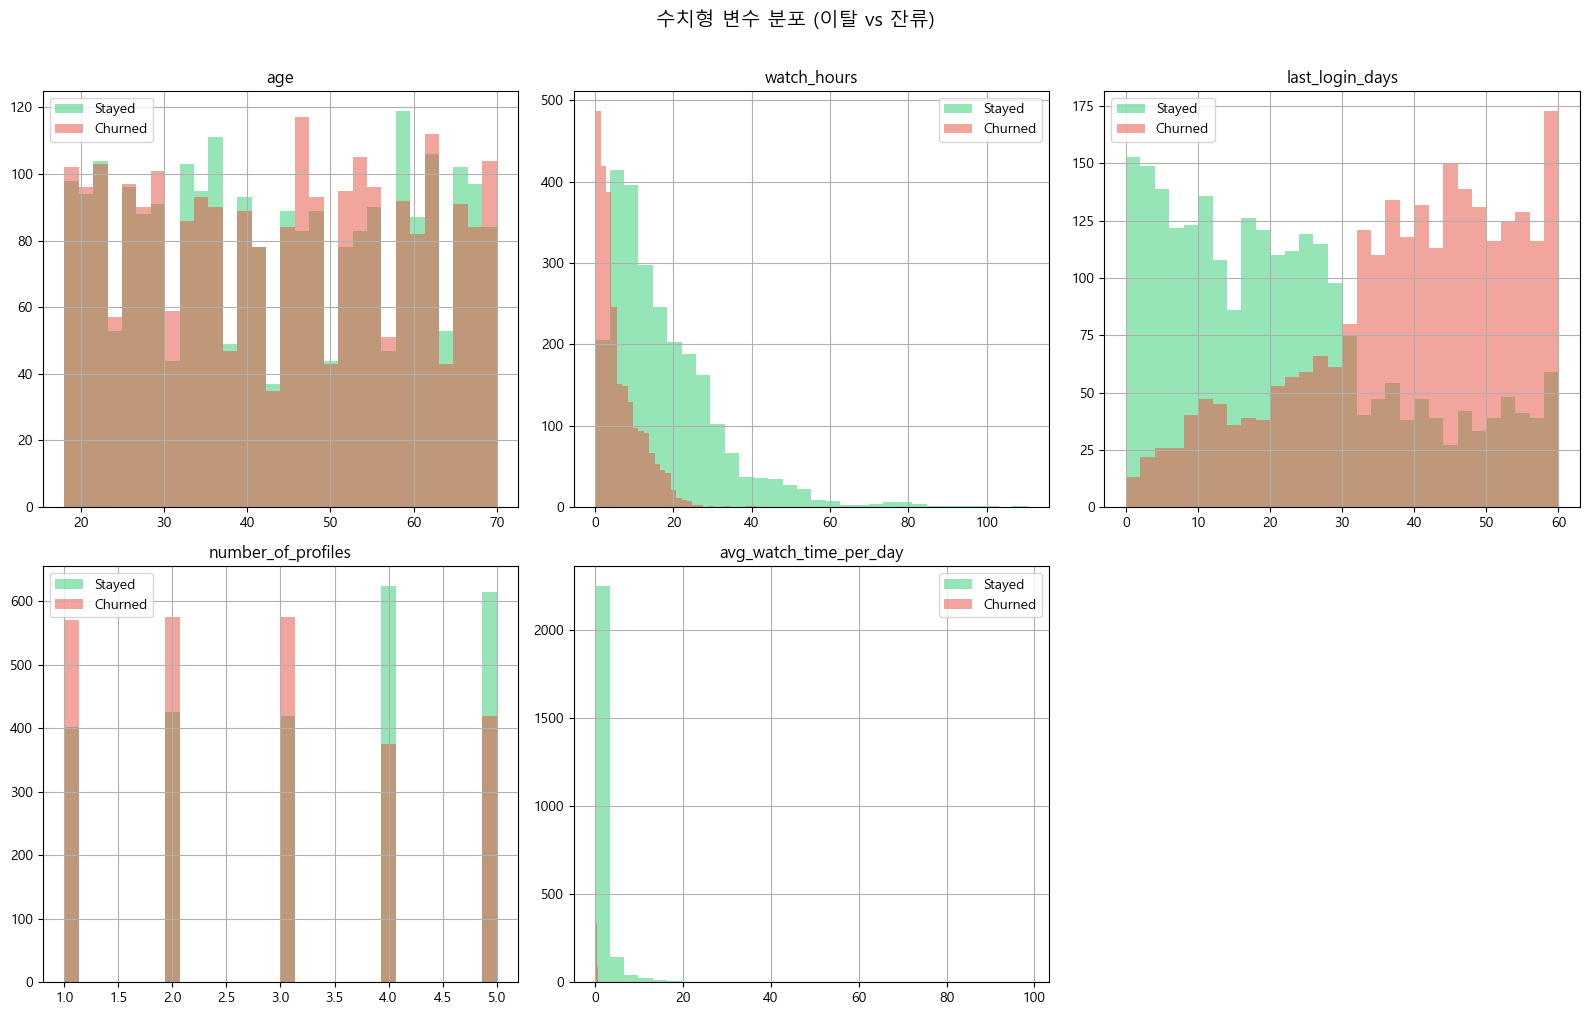

In [22]:
numeric_cols = ['age', 'watch_hours', 'last_login_days', 'number_of_profiles', 'avg_watch_time_per_day']

# 이탈/잔류별 히스토그램
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[df['churned'] == 0][col].hist(bins=30, alpha=0.5, color='#2ecc71', label='Stayed', ax=axes[i])
    df[df['churned'] == 1][col].hist(bins=30, alpha=0.5, color='#e74c3c', label='Churned', ax=axes[i])
    axes[i].set_title(col, fontsize=12)
    axes[i].legend()

axes[5].axis('off')
plt.suptitle('수치형 변수 분포 (이탈 vs 잔류)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

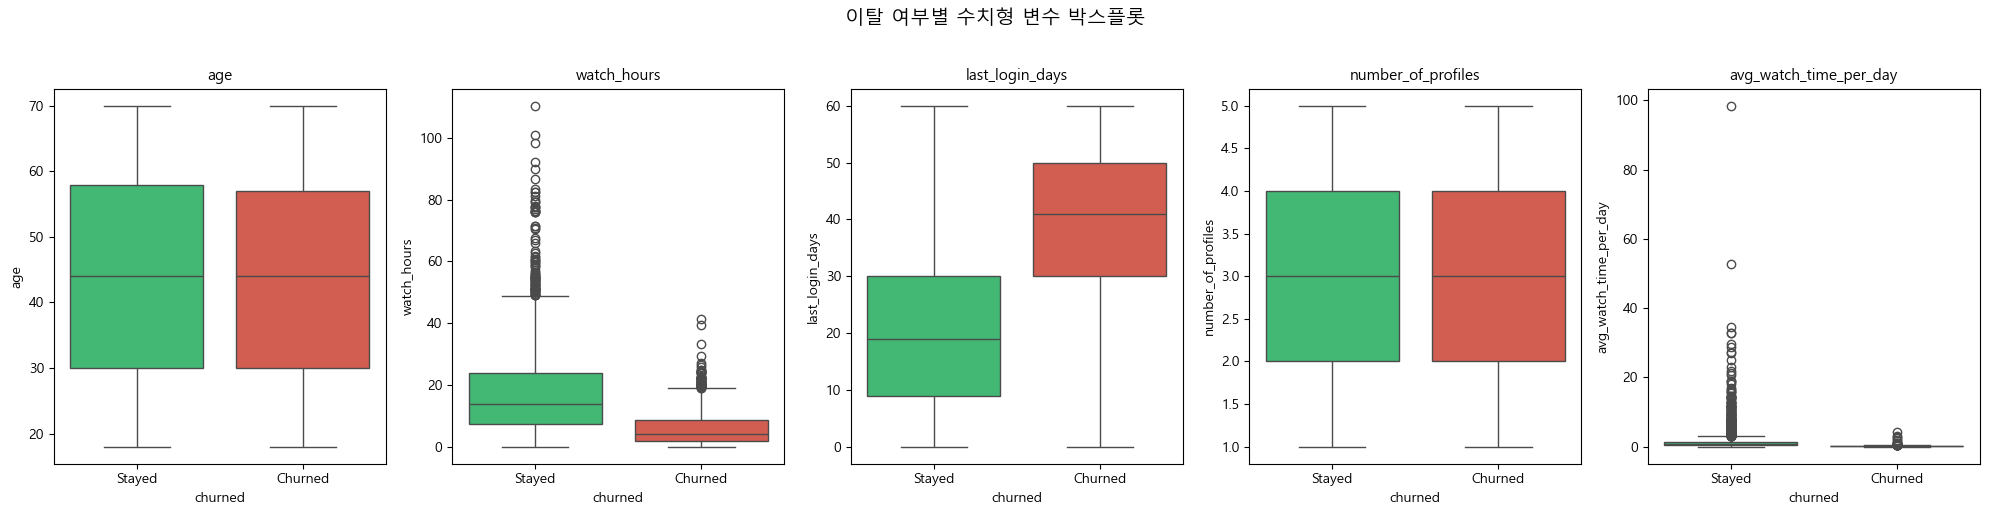

In [23]:
# 이탈 여부별 박스플롯
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='churned', y=col,
                palette=['#2ecc71', '#e74c3c'], ax=axes[i])
    axes[i].set_xticklabels(['Stayed', 'Churned'])
    axes[i].set_title(col, fontsize=11)

plt.suptitle('이탈 여부별 수치형 변수 박스플롯', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [24]:
# 이탈 vs 잔류 평균값 비교표
print('=== 이탈 vs 잔류 평균 비교 ===')
comparison = df.groupby('churned')[numeric_cols].mean().round(2)
comparison.index = ['Stayed', 'Churned']
comparison.T

=== 이탈 vs 잔류 평균 비교 ===


,Stayed,Churned
age,43.90,43.79
watch_hours,17.45,5.92
last_login_days,21.77,38.31
number_of_profiles,3.25,2.80
avg_watch_time_per_day,1.59,0.16


---
## 3. 범주형 변수별 이탈 비율 비교
- 성별, 구독유형, 지역, 기기, 결제수단, 선호장르 각각의 이탈률
- 구독유형 x 지역/기기/장르 교차 이탈률 비교

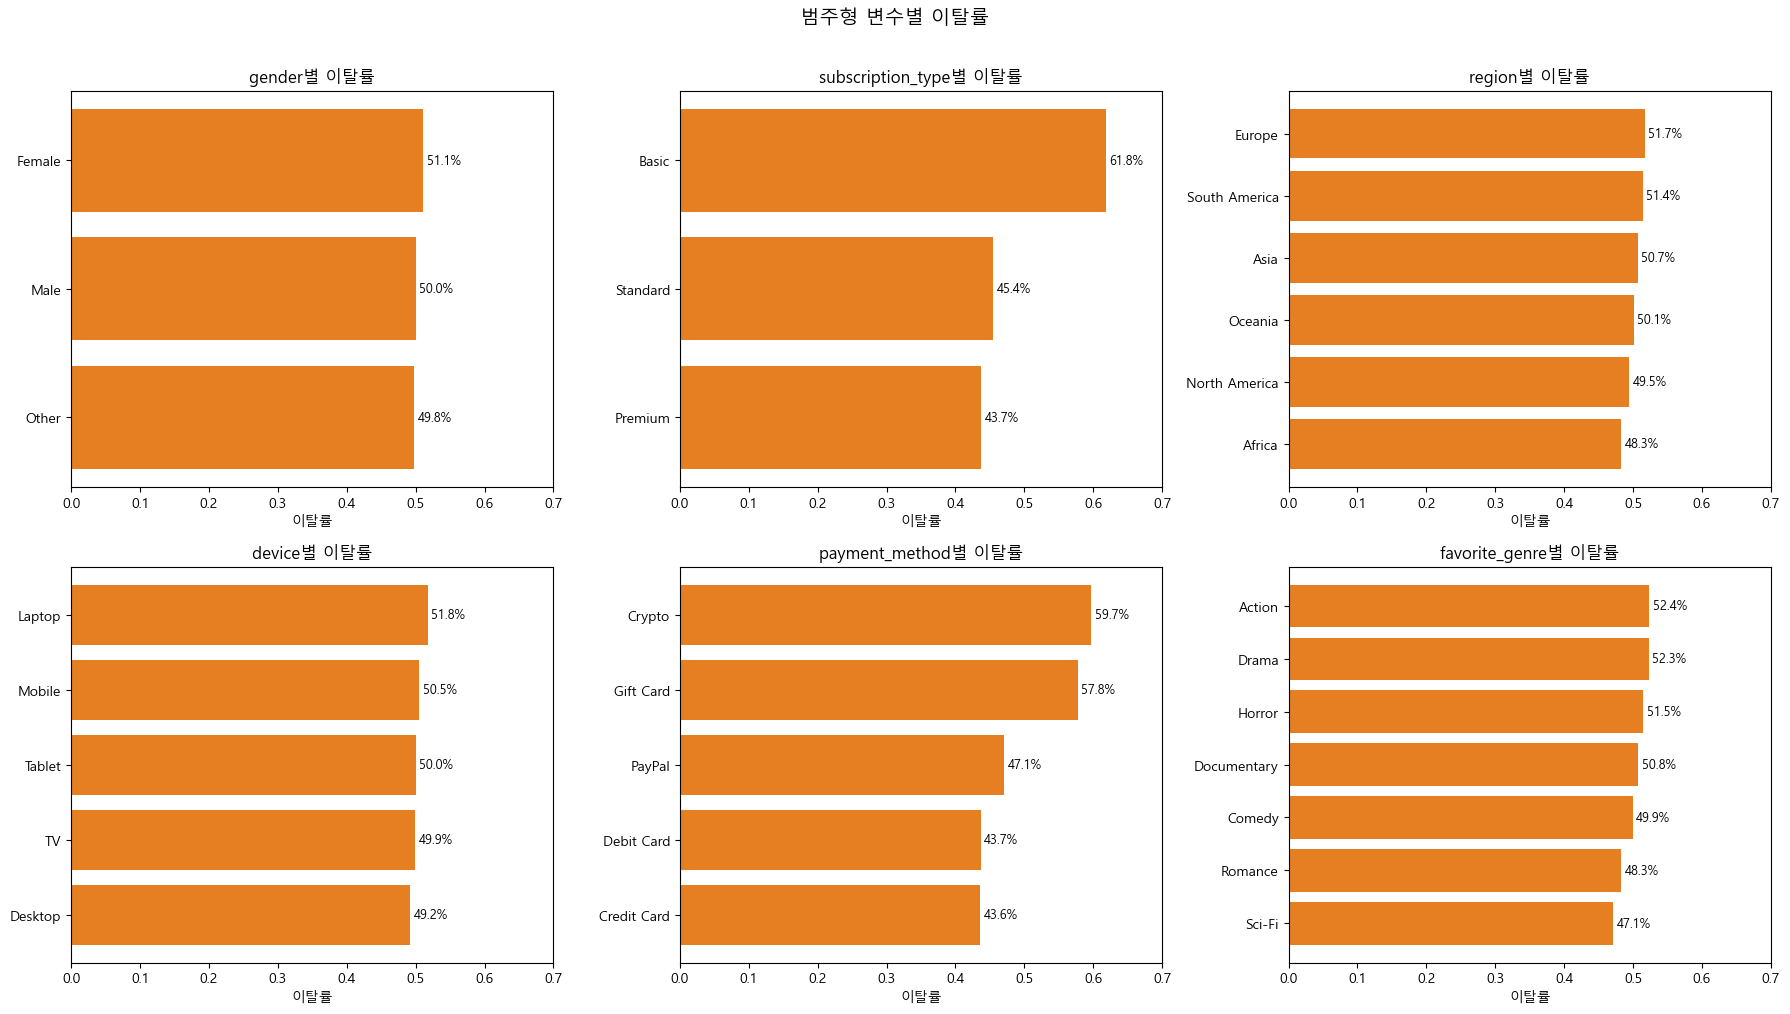

In [25]:
# 6개 범주형 변수별 이탈률 바차트
cat_cols = ['gender', 'subscription_type', 'region', 'device', 'payment_method', 'favorite_genre']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['churned'].mean().sort_values(ascending=True)
    bars = axes[i].barh(churn_rate.index, churn_rate.values, color='#e67e22')
    for j, v in enumerate(churn_rate.values):
        axes[i].text(v + 0.005, j, f'{v:.1%}', va='center', fontsize=9)
    axes[i].set_title(f'{col}별 이탈률', fontsize=12)
    axes[i].set_xlabel('이탈률')
    axes[i].set_xlim(0, 0.7)

plt.suptitle('범주형 변수별 이탈률', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

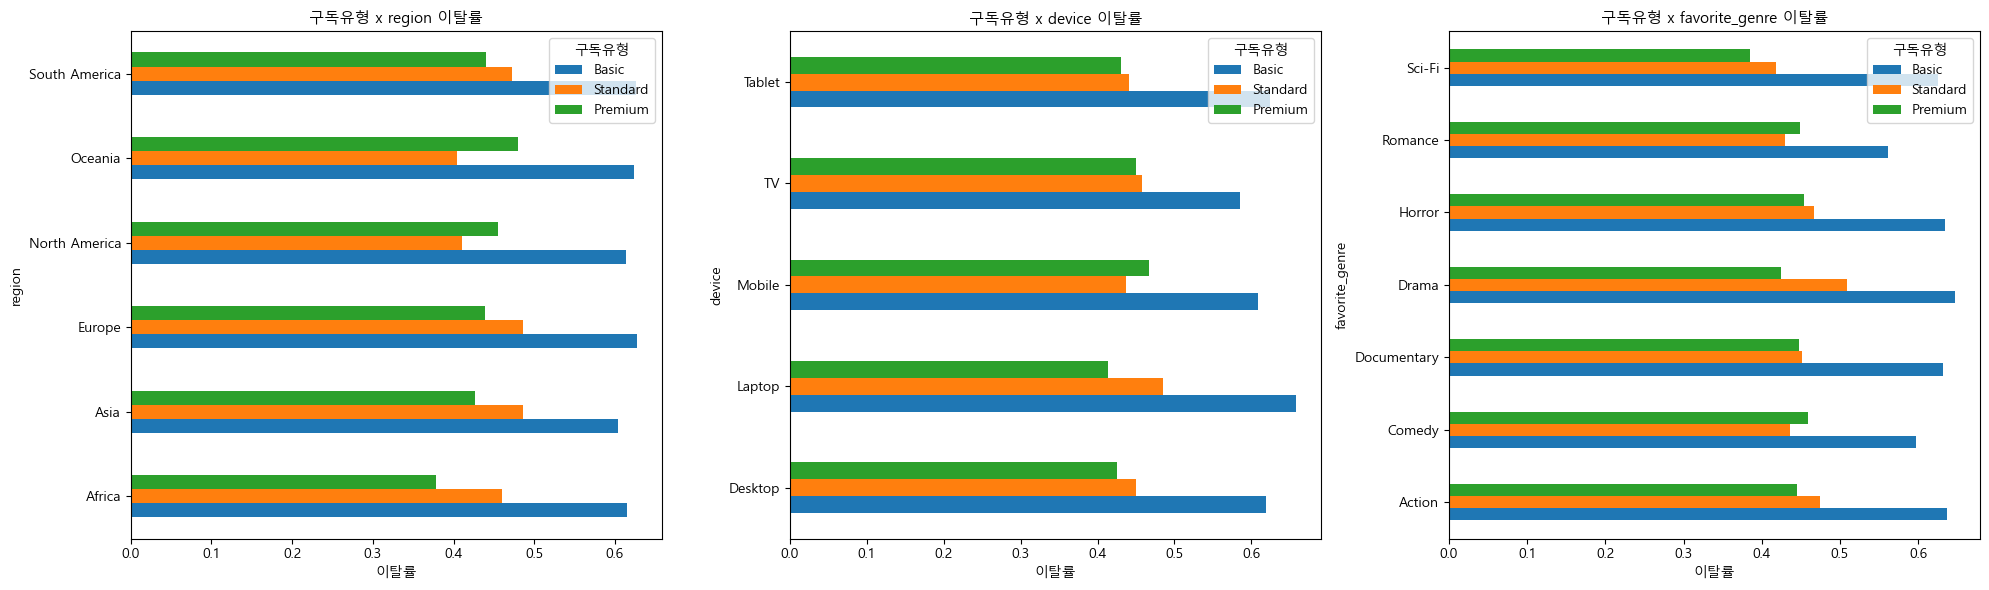

In [26]:
# 구독유형 x 범주형 교차 이탈률
cross_cols = ['region', 'device', 'favorite_genre']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, col in enumerate(cross_cols):
    pivot = df.pivot_table(index=col, columns='subscription_type',
                           values='churned', aggfunc='mean')
    pivot[['Basic', 'Standard', 'Premium']].plot(kind='barh', ax=axes[i])
    axes[i].set_title(f'구독유형 x {col} 이탈률', fontsize=11)
    axes[i].set_xlabel('이탈률')
    axes[i].legend(title='구독유형')

plt.tight_layout()
plt.show()

---
## 4. 수치형 변수와 이탈의 관계 시각화
- 마지막 로그인 경과일 구간별 이탈률
- 일 평균 시청시간 구간별 이탈률
- 나이대별 이탈률

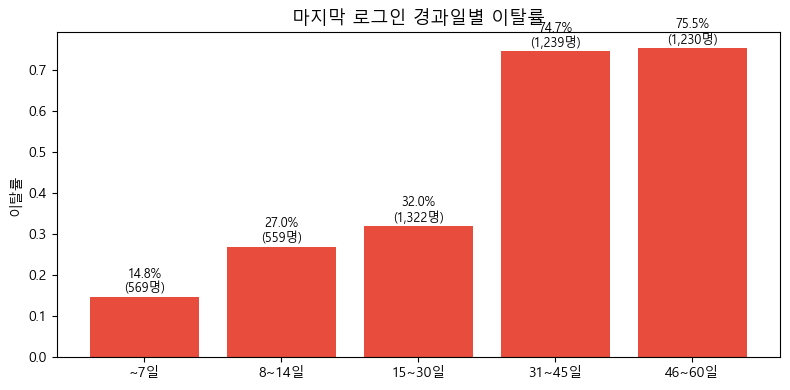

In [27]:
# 마지막 로그인 경과일 구간별 이탈률
df['login_group'] = pd.cut(df['last_login_days'],
                           bins=[0, 7, 14, 30, 45, 60],
                           labels=['~7일', '8~14일', '15~30일', '31~45일', '46~60일'])

login_stats = df.groupby('login_group', observed=True)['churned'].agg(['mean', 'count'])
login_stats.columns = ['이탈률', '고객수']

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(login_stats.index.astype(str), login_stats['이탈률'], color='#e74c3c')
for i, (rate, cnt) in enumerate(zip(login_stats['이탈률'], login_stats['고객수'])):
    ax.text(i, rate + 0.01, f'{rate:.1%}\n({cnt:,}명)', ha='center', fontsize=9)
ax.set_title('마지막 로그인 경과일별 이탈률', fontsize=13)
ax.set_ylabel('이탈률')
plt.tight_layout()
plt.show()

df = df.drop(columns=['login_group'])

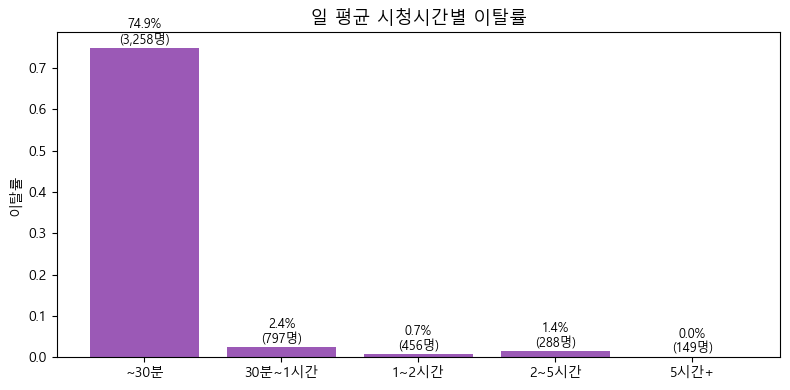

In [28]:
# 일 평균 시청시간 구간별 이탈률
df['watch_group'] = pd.cut(df['avg_watch_time_per_day'],
                           bins=[0, 0.5, 1, 2, 5, 100],
                           labels=['~30분', '30분~1시간', '1~2시간', '2~5시간', '5시간+'])

watch_stats = df.groupby('watch_group', observed=True)['churned'].agg(['mean', 'count'])
watch_stats.columns = ['이탈률', '고객수']

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(watch_stats.index.astype(str), watch_stats['이탈률'], color='#9b59b6')
for i, (rate, cnt) in enumerate(zip(watch_stats['이탈률'], watch_stats['고객수'])):
    ax.text(i, rate + 0.01, f'{rate:.1%}\n({cnt:,}명)', ha='center', fontsize=9)
ax.set_title('일 평균 시청시간별 이탈률', fontsize=13)
ax.set_ylabel('이탈률')
plt.tight_layout()
plt.show()

df = df.drop(columns=['watch_group'])

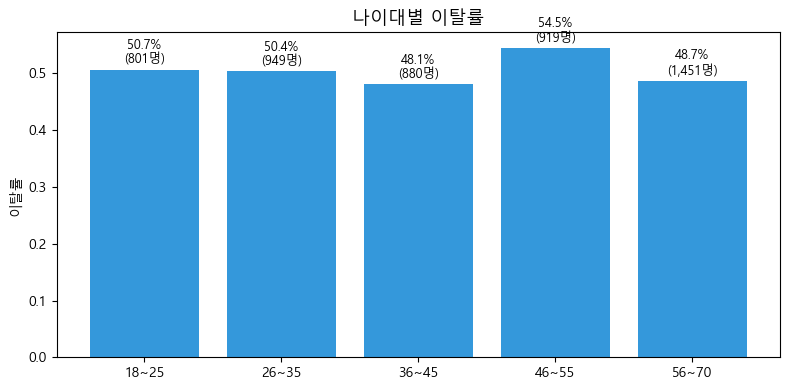

In [29]:
# 나이대별 이탈률
df['age_group'] = pd.cut(df['age'],
                         bins=[17, 25, 35, 45, 55, 70],
                         labels=['18~25', '26~35', '36~45', '46~55', '56~70'])

age_stats = df.groupby('age_group', observed=True)['churned'].agg(['mean', 'count'])
age_stats.columns = ['이탈률', '고객수']

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(age_stats.index.astype(str), age_stats['이탈률'], color='#3498db')
for i, (rate, cnt) in enumerate(zip(age_stats['이탈률'], age_stats['고객수'])):
    ax.text(i, rate + 0.01, f'{rate:.1%}\n({cnt:,}명)', ha='center', fontsize=9)
ax.set_title('나이대별 이탈률', fontsize=13)
ax.set_ylabel('이탈률')
plt.tight_layout()
plt.show()

df = df.drop(columns=['age_group'])

---
## 5. 상관관계 확인
- 수치형 변수 간 상관관계 히트맵 (churned 포함)

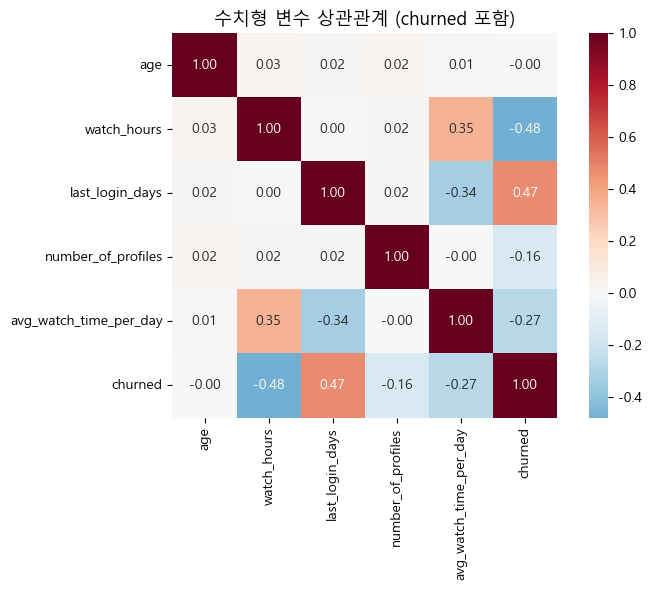

In [30]:
corr_cols = ['age', 'watch_hours', 'last_login_days', 'number_of_profiles', 'avg_watch_time_per_day', 'churned']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax)
ax.set_title('수치형 변수 상관관계 (churned 포함)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 6. EDA 인사이트 정리

### 4가지 중점 분석 결과

1. **최근 로그인 일수가 많을수록 이탈 증가하는지?**
   - (위 시각화 결과를 바탕으로 작성)

2. **시청 시간이 낮은 고객이 더 잘 이탈하는지?**
   - (위 시각화 결과를 바탕으로 작성)

3. **Basic 요금제 고객 이탈률이 높은지?**
   - (위 시각화 결과를 바탕으로 작성)

4. **특정 결제 수단에서 이탈이 높은지?**
   - (위 시각화 결과를 바탕으로 작성)

> 실행 후 그래프를 보고 해석을 채워넣으세요.